In [ ]:
!pip install arxiv pandas matplotlib PyMuPDF

In [ ]:
import requests
import pandas as pd
import time
def extraer_datos_openalex(query, year_start=1975, year_end=2025):
    """Extrae el volumen de publicaciones por año de la API de OpenAlex."""
    url = "https://api.openalex.org/works"
    params = {
        "search": query,
        "group_by": "publication_year",
        "filter": f"publication_year:{year_start}-{year_end}"
    }
    headers = {"User-Agent": "mailto:tu_correo@ejemplo.com"}
    try:
        response = requests.get(url, params=params, headers=headers)
        if response.status_code == 200:
            data = response.json()
            return {int(item['key']): item['count'] for item in data.get('group_by', [])}
        else:
            print(f"Error consultando '{query}': HTTP {response.status_code}")
            return {}
    except Exception as e:
        print(f"Error de red: {e}")
        return {}
baseline_query = '"Finance" OR "Economics"'
categorias = {
    "Era Analítica y Complejidad": '"Option Pricing" OR "Black-Scholes" OR "Stochastic Volatility"',
    "Nacimiento del Riesgo Global": '"Value at Risk" OR ("VaR" AND "Finance")',
    "Expected Shortfall Post-2008": '"Expected Shortfall" OR "Conditional Value at Risk" OR "CVaR"',
    "Cuello de Botella Computacional": '("Monte Carlo") AND ("Computational efficiency" OR "GPU" OR "Parallel computing" OR "High performance computing")'
}
print("Iniciando descarga de datos (por favor, espera unos segundos)...")
datos_crudos = {}
datos_crudos["Baseline"] = extraer_datos_openalex(baseline_query)
time.sleep(1)
for nombre, query in categorias.items():
    print(f"Descargando: {nombre}...")
    datos_crudos[nombre] = extraer_datos_openalex(query)
    time.sleep(1.5)
años = range(1975, 2025)
df_relativo = pd.DataFrame(index=años)
serie_baseline = pd.Series(datos_crudos["Baseline"])
for nombre in categorias.keys():
    serie_tema = pd.Series(datos_crudos[nombre])
    df_relativo[nombre] = (serie_tema / serie_baseline * 10000).fillna(0)
nombre_archivo = 'datos_tfm_estado_arte.csv'
df_relativo.index.name = 'Año'
df_relativo.to_csv(nombre_archivo)
print(f"\n¡Éxito! Datos guardados en '{nombre_archivo}'. Ya no necesitas llamar a la API.")

Datos cargados y actualizados correctamente.
Gráfico exportado correctamente en alta resolución y con fuentes extra grandes.


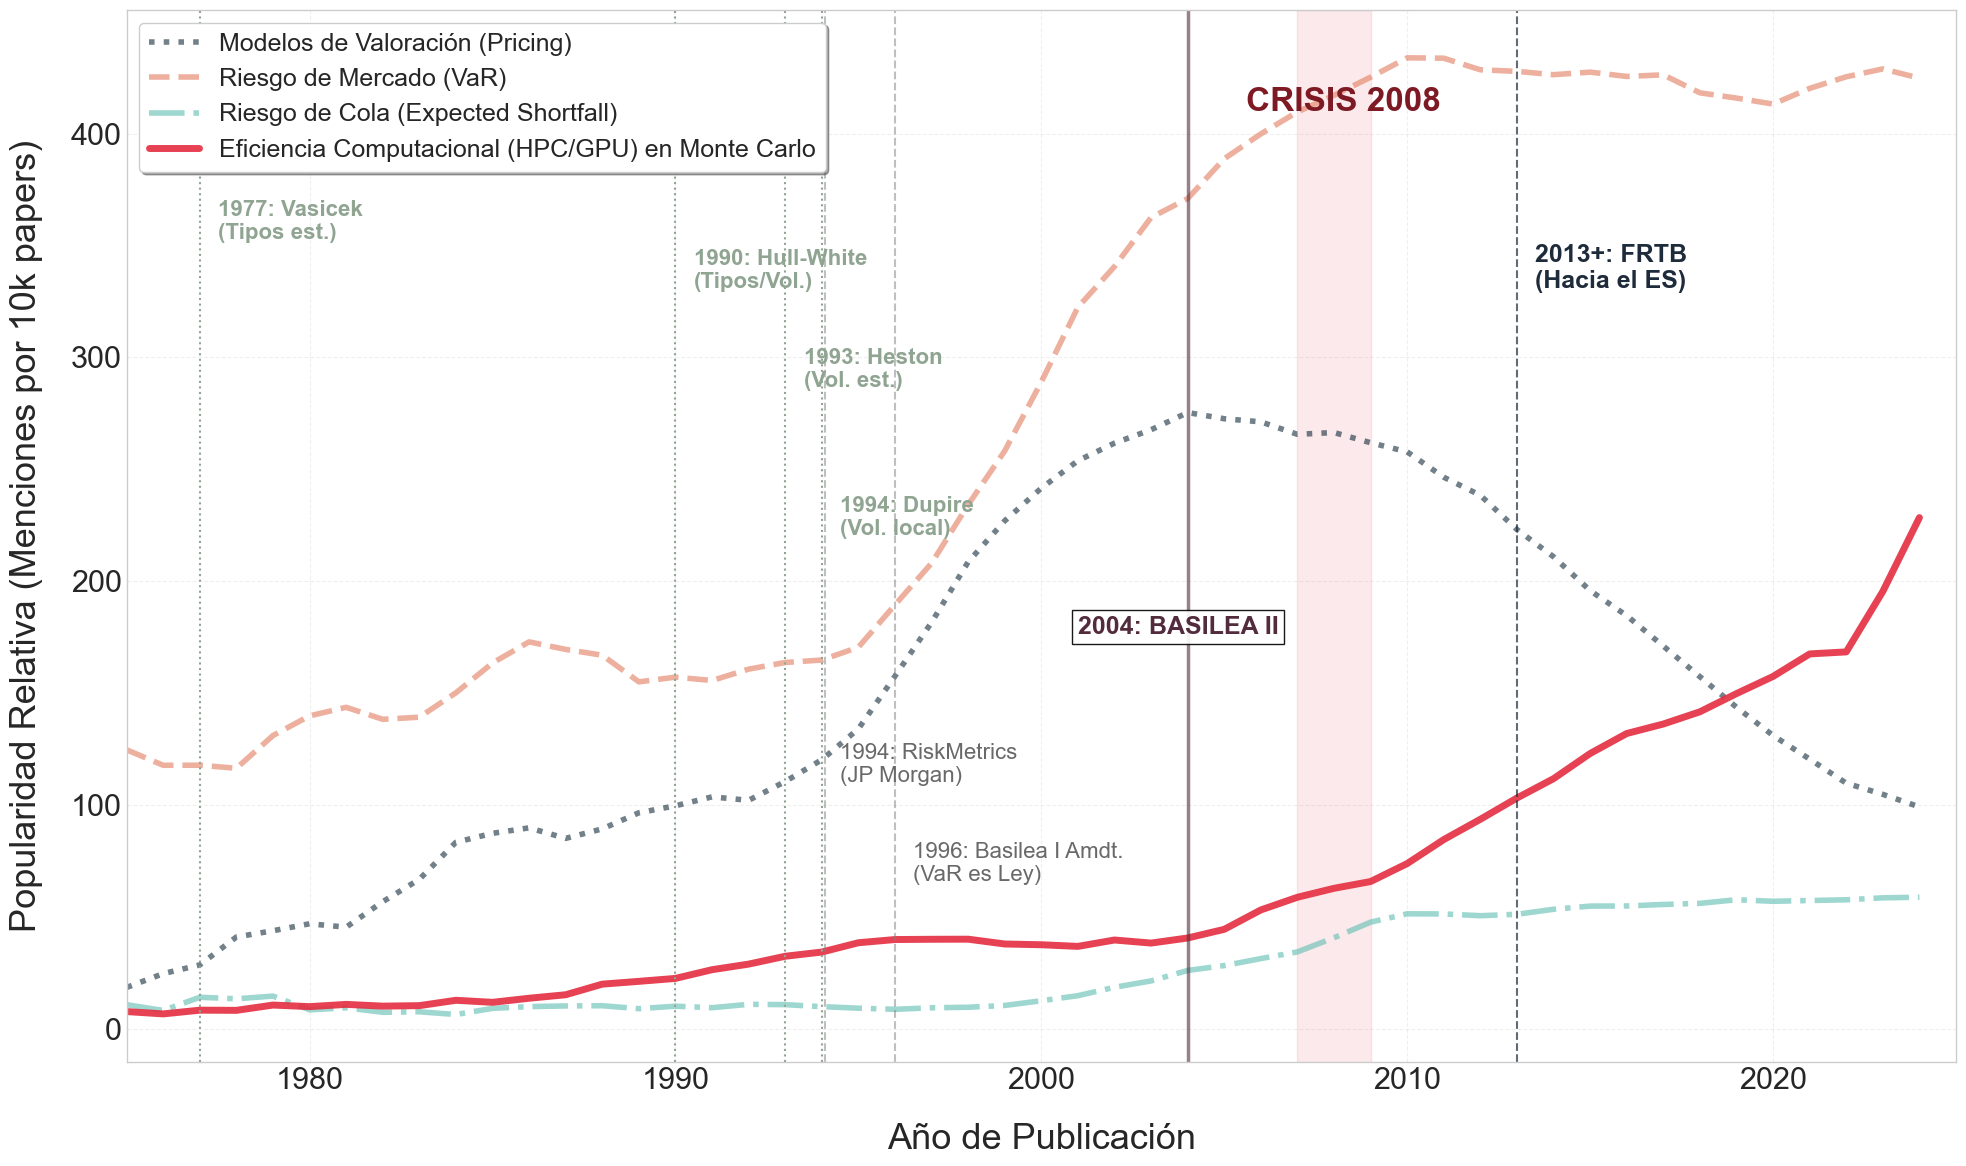

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
try:
    df_relativo = pd.read_csv('datos_tfm_estado_arte.csv', index_col='Año')
    nuevos_nombres = {
        "Era Analítica y Complejidad": "Modelos de Valoración (Pricing)",
        "Nacimiento del Riesgo Global": "Riesgo de Mercado (VaR)",
        "Riesgo de Cola Post-2008": "Riesgo de Cola (Expected Shortfall)",
        "Cuello de Botella Computacional": "Eficiencia Computacional (HPC/GPU) en Monte Carlo"
    }
    df_relativo.rename(columns=nuevos_nombres, inplace=True)
    print("Datos cargados y actualizados correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra 'datos_tfm_estado_arte.csv'.")
    exit()
fig, ax = plt.subplots(figsize=(20, 12))
colores = {
    "Modelos de Valoración (Pricing)": "#142b3b",
    "Riesgo de Mercado (VaR)": "#e47c5d",
    "Riesgo de Cola (Expected Shortfall)": "#5ebdb2",
    "Eficiencia Computacional (HPC/GPU) en Monte Carlo": "#e42d40"
}
estilos = [':', '--', '-.', '-']
for i, col in enumerate(df_relativo.columns):
    suavizado = df_relativo[col].rolling(window=3, min_periods=1).mean()
    lw = 5 if i >= 3 else 4
    alpha = 0.9 if i >= 3 else 0.6
    ax.plot(suavizado.index, suavizado, label=col, linewidth=lw,
            linestyle=estilos[i], color=colores.get(col, 'black'), alpha=alpha)
max_y = df_relativo.max().max()
anotaciones_pricing = [
    (1977, '1977: Vasicek\n(Tipos est.)'),
    (1990, '1990: Hull-White\n(Tipos/Vol.)'),
    (1993, '1993: Heston\n(Vol. est.)'),
    (1994, '1994: Dupire\n(Vol. local)')
]
for año, texto in anotaciones_pricing:
    ax.axvline(x=año, color='#90a492', linestyle=':', alpha=1)
    offset = 0.80 if año == 1977 else (0.75 if año == 1990 else (0.65 if año == 1993 else 0.50))
    ax.text(año + 0.5, max_y * offset, texto, color='#90a492', fontsize=16, fontweight='bold')
ax.axvline(x=1994.1, color='grey', linestyle='--', alpha=0.5)
ax.text(1994.5, max_y * 0.25, '1994: RiskMetrics\n(JP Morgan)', color='dimgrey', fontsize=16)
ax.axvline(x=1996, color='grey', linestyle='--', alpha=0.5)
ax.text(1996.5, max_y * 0.15, '1996: Basilea I Amdt.\n(VaR es Ley)', color='dimgrey', fontsize=16)
ax.axvline(x=2004, color='#522b3c', linestyle='-', linewidth=2.5, alpha=0.6)
ax.text(2001, max_y * 0.4, '2004: BASILEA II',
        color="#522b3c", fontsize=18, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9))
ax.axvspan(2007, 2009, color="#e42d3f", alpha=0.1)
ax.text(2005.6, max_y * 0.93, 'CRISIS 2008', color="#7e1a24", fontsize=24, fontweight='bold')
ax.axvline(x=2013, color='#1e2b3b', linestyle='--', alpha=0.7)
ax.text(2013.5, max_y * 0.75, '2013+: FRTB\n(Hacia el ES)', color='#1e2b3b', fontsize=18, fontweight='bold')
ax.set_ylabel('Popularidad Relativa (Menciones por 10k papers)', fontsize=26, labelpad=20)
ax.set_xlabel('Año de Publicación', fontsize=26, labelpad=20)
ax.set_xlim(1975, 2025)
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('evolucion_cuant_tfm.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Gráfico exportado correctamente en alta resolución y con fuentes extra grandes.")
plt.show()